# Task 1 — Vanilla GAN on MNIST using PyTorch

In this notebook, we implement a simple Vanilla GAN to generate MNIST-like digit images.

We will:
1. Load the MNIST dataset
2. Build the Generator and Discriminator
3. Train the GAN
4. Visualize generated samples

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import global_config as gc
from utils import device_check, show_generated_images, build_model_name
from GAN import Generator, Discriminator, train_GAN

## General setup

In [2]:
LOG_WANDB = True
SEED = 1

# Device setup
device = device_check()

# Reproducibility
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)
    # Enable cuDNN auto-tuner for fixed-size inputs
    torch.backends.cudnn.benchmark = True
    # Data loading settings
    PIN_MEMORY = True
    NUM_WORKERS = 8
    PERSISTENT_WORKERS = True
    PREFETCH_FACTOR = 4
else:
    # Data loading settings
    PIN_MEMORY = False
    NUM_WORKERS = 0
    PERSISTENT_WORKERS = False
    PREFETCH_FACTOR = 2

PyTorch: 2.11.0+cu130 | Python: 3.11.15 | OS: Linux 5.15.0-168-generic
CUDA available: True
GPUs: 1 x NVIDIA GeForce RTX 2080 Ti (11.3 GB)
CUDA: 13.0 | cuDNN: 91900
Using cuda / NVIDIA GeForce RTX 2080 Ti


## Load MNIST dataset

In [3]:
BATCH_SIZE = 256

# Transform pipeline for MNIST
transform = transforms.Compose([
    transforms.ToTensor() # Scales pixel values from [0, 255] to [0, 1]
])

# Download and load the training set
train_dataset = datasets.MNIST(
    root=gc.DATA_DIR,
    train=True,
    transform=transform,
    download=True
)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    drop_last=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT_WORKERS,
    prefetch_factor=PREFETCH_FACTOR,
)

print("Number of training samples:", len(train_dataset))
print("Number of batches per epoch:", len(train_loader))

Number of training samples: 60000
Number of batches per epoch: 234


## Visualize a few real images

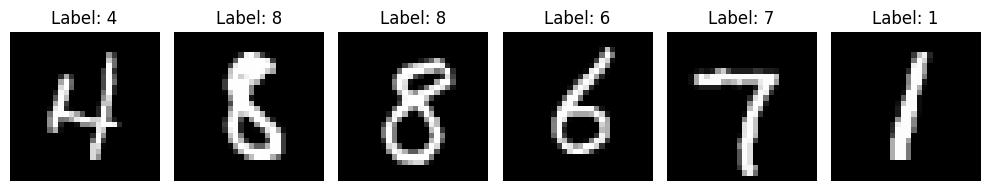

In [4]:
# Get one batch of real images
real_images, real_labels = next(iter(train_loader))

# Plot a few images from the batch
fig, axes = plt.subplots(1, 6, figsize=(10, 2))
for i in range(6):
    axes[i].imshow(real_images[i].squeeze(), cmap="gray")
    axes[i].set_title(f"Label: {real_labels[i].item()}")
    axes[i].axis("off")

plt.tight_layout()
plt.show()

## Initialize models

In [5]:
LATENT_DIM = 100
G_HIDDEN_DIM = 128
D_HIDDEN_DIM = 128
IMAGE_DIM = 28 * 28

G = Generator(
    z_dim=LATENT_DIM,
    h_dim=G_HIDDEN_DIM,
    x_dim=IMAGE_DIM,
).to(device)

D = Discriminator(
    x_dim=IMAGE_DIM,
    h_dim=D_HIDDEN_DIM,
).to(device)

print(G)
print()
print(D)

Generator(
  (fc1): Linear(in_features=100, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=784, bias=True)
)

Discriminator(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=1, bias=True)
)


## Define optimizers

No criterion object is defined here. The lab's starter code used `nn.Sigmoid()` as the Discriminator's final activation paired with `nn.BCELoss()`, but we replaced this with `nn.BCEWithLogitsLoss()` (and removed the sigmoid from the Discriminator) for two reasons:

**Numerical stability.** `BCELoss` requires probabilities as input. When the Discriminator is confident, sigmoid outputs saturate near 0 or 1, and `log(0)` produces `-inf`. `BCEWithLogitsLoss` fuses the sigmoid and the logarithm via the log-sum-exp trick, avoiding this.

**AMP (float16) incompatibility.** Under `torch.autocast` on CUDA, computations run in float16. Values very close to 0 or 1 are rounded to exactly `0.0` or `1.0` in float16, so `BCELoss` encounters `log(0)` and produces `NaN` gradients. PyTorch's documentation explicitly marks `BCELoss` as unsafe inside an autocast context. `BCEWithLogitsLoss` operates on raw logits and is safe under float16.

Mathematically the two are identical in exact arithmetic — the change is purely about numerical robustness. The loss is computed inside `train_GAN` via `GAN.py`.

In [ ]:
LR = 1e-3
BETAS = (0.9, 0.999)

g_optimizer = optim.Adam(G.parameters(), lr=LR, betas=BETAS)
d_optimizer = optim.Adam(D.parameters(), lr=LR, betas=BETAS)

## Train the Vanilla GAN

In [ ]:
EPOCHS = 1500

config = {
    "epochs": EPOCHS,
    "latent_dim": LATENT_DIM,
    "image_dim": IMAGE_DIM,
    "batch_size": BATCH_SIZE,
    "g_lr": LR,
    "d_lr": LR,
    "g_hidden_dim": G_HIDDEN_DIM,
    "d_hidden_dim": D_HIDDEN_DIM,
    "betas": BETAS,
    "optimizer": "Adam",
    "dataset": "MNIST",
    "model": "Vanilla GAN",
    "seed": SEED,
}

wandb_kwargs = dict(
    entity=gc.WANDB_ENTITY,
    project=gc.WANDB_PROJECT,
    name="Vanilla GAN BCE",
    tags=["Task 1", "MNIST", "Vanilla GAN"],
    dir=str(gc.WANDB_DIR),
    config=config,
    mode="online" if LOG_WANDB else "disabled",
)

train_GAN(
    G=G,
    D=D,
    train_loader=train_loader,
    g_optimizer=g_optimizer,
    d_optimizer=d_optimizer,
    config=config,
    device=device,
    wandb_kwargs=wandb_kwargs,
)

## Display final generated samples

In [ ]:
show_generated_images(G, LATENT_DIM, device)